In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split

N_SAMPLES = 20
x = np.linspace(0,1,num=N_SAMPLES).reshape(-1,1)

np.random.seed(42)

def ground_truth(x):
    return 4 * x + np.sin(x*6)

t = ground_truth(x) + 0.5 * np.random.randn(N_SAMPLES,1)

x_train, x_test, t_train, t_test = train_test_split(x, t, random_state=42)


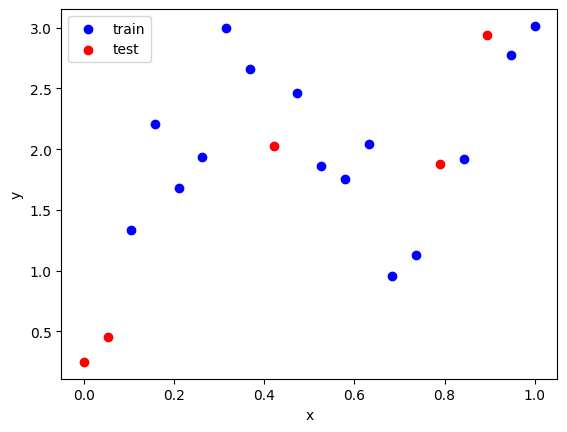

In [ ]:
plt.scatter(x_train, t_train, c='blue', label='train')
plt.scatter(x_test, t_test, c='red', label='test')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Regresión lineal a mano


Si queremos obtener los estimador de maxima verosimilitud de los pesos $\beta_{0}$, $\beta_{1}$, tenemos que resolver las ecuaciones normales

$$\beta_{ML}=(X^{T}X)^{-1}X^{T}t$$

Donde $\beta_{ML}=(\beta_{0,ML},\beta_{1,ML})^{T}$, $t$ el vector de target y $X$ es la matriz de diseño. En cada columna, tiene una de las funciones de base. En este caso, 1 y x. En cada fila, tiene una medicion

Si tenemos M funciones de base y N mediciones,

$\beta_{ML}$ es una matriz de $M \text{ x } 1 $

$X$ es una matriz de $N \text{ x } M$

$t$ es una matriz de $N \text{ x } 1$

In [ ]:
X_train=np.vstack([np.ones(len(x_train)),x_train[:,0]]).T # agrupo 1s y xs para cada medicion

In [ ]:
X_train.shape

(15, 2)

In [ ]:
print(x_train[0],X_train[0])

[0.26315789] [1.         0.26315789]


Las ecuaciones normales tienen una inversa ahi metida. Eso no es numericamente muy deseable. Conviene resolver la ecuacion

$$(X^{T}X)\beta_{ML}=X^{T}t$$

y utilizar `np.linalg.solve(A,b)` que obtiene el vector $x$ solucion de la ecuacion

$$Ax=b$$

In [ ]:
A=np.dot(X_train.T,X_train)
b=np.dot(X_train.T,t_train)
beta_ML=np.linalg.solve(A,b)

Veamos la solucion

In [ ]:
beta_ML

array([[1.85999881],
       [0.36019965]])

In [ ]:
def y_ML(x,wML):
  return wML[0]+wML[1]*x

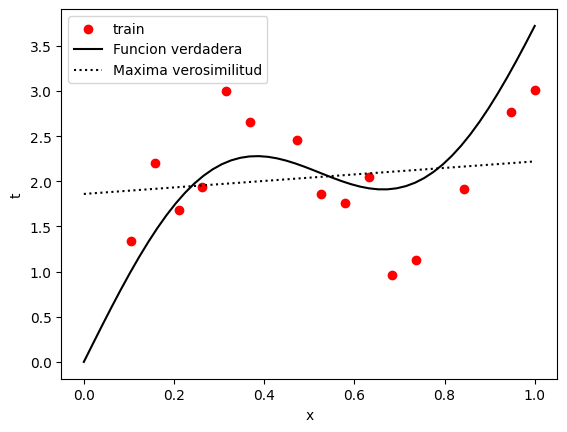

In [ ]:
xvals=np.linspace(0,1,num=50).reshape(-1,1)
plt.scatter(x_train,t_train, c='red', label='train')
plt.plot(xvals,ground_truth(xvals),color='black',label='Funcion verdadera')
plt.plot(xvals,y_ML(xvals,beta_ML),color='black',linestyle='dotted',label='Maxima verosimilitud')
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.show()

Obviamente, no funciona muy bien...

## Polinómios

Reescribimos las ecuaciones normales, pero ahora modelando la funcion como polinomios:

$$y(x,w)=w_{0}+\sum_{i=1}^{J}w_{i}x^{i}$$

In [ ]:
X_train=np.vstack([np.ones(len(x_train)),x_train[:,0],x_train[:,0]**2,x_train[:,0]**3,x_train[:,0]**4, x_train[:,0]**5]).T # agrupo 1s y xs para cada medicion

In [ ]:
X_train.shape

(15, 6)

In [ ]:
print(x_train[0],X_train[0])

[0.26315789] [1.         0.26315789 0.06925208 0.01822423 0.00479585 0.00126207]


Las ecuaciones normales tienen una inversa ahi metida. Eso no es numericamente muy deseable. Conviene resolver la ecuacion

$$(X^{T}X)\beta_{ML}=X^{T}t$$

y utilizar `np.linalg.solve(A,b)` que obtiene el vector $X$ solucion de la ecuacion

$$Ax=b$$

In [ ]:
A=np.dot(X_train.T,X_train)
b=np.dot(X_train.T,t_train)
beta_ML=np.linalg.solve(A,b)

Veamos la solucion

In [ ]:
beta_ML

array([[   3.07455312],
       [ -33.29841562],
       [ 231.85595842],
       [-584.70043894],
       [ 604.71681963],
       [-218.60955573]])

In [ ]:
def y_ML_poly(x,wML):
  return wML[0]+wML[1]*x+wML[2]*x**2+wML[3]*x**3+wML[4]*x**4+wML[5]*x**5

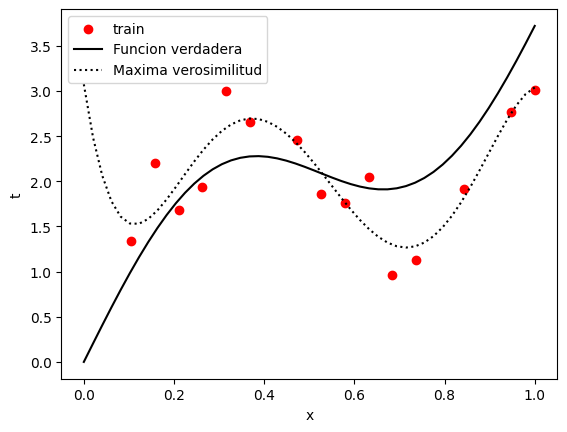

In [ ]:
xvals=np.linspace(0,1,num=50).reshape(-1,1)
plt.scatter(x_train,t_train, c='red', label='train')
plt.plot(xvals,ground_truth(xvals),color='black',label='Funcion verdadera')
plt.plot(xvals,y_ML_poly(xvals,beta_ML),color='black',linestyle='dotted',label='Maxima verosimilitud')
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.show()

## Funciones de base reales

$$y(x,w)=w_{0}+w_{1}x+w_{2}sen(6x)$$

In [ ]:
X_train=np.vstack([np.ones(len(x_train)),x_train[:,0],np.sin(x_train[:,0]*6)]).T # agrupo 1s y xs para cada medicion

A=np.dot(X_train.T,X_train)
b=np.dot(X_train.T,t_train)
beta_ML=np.linalg.solve(A,b)

In [ ]:
def y_ML_poly(x,wML):
  return wML[0]+wML[1]*x+wML[2]*np.sin(6*x)

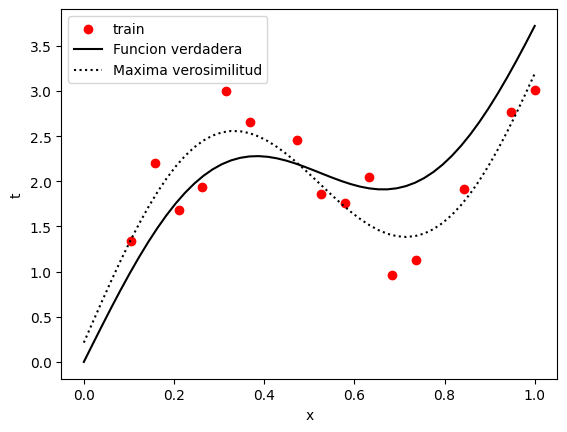

In [ ]:
xvals=np.linspace(0,1,num=50).reshape(-1,1)
plt.scatter(x_train,t_train, c='red', label='train')
plt.plot(xvals,ground_truth(xvals),color='black',label='Funcion verdadera')
plt.plot(xvals,y_ML_poly(xvals,beta_ML),color='black',linestyle='dotted',label='Maxima verosimilitud')
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.show()

## Sklearn

In [ ]:
# Define function to perform pipeline for a given degree.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

PolynomialFeatures(degree=1, include_bias=True).fit_transform(x_train)

array([[1.        , 0.26315789],
       [1.        , 0.57894737],
       [1.        , 0.15789474],
       [1.        , 0.94736842],
       [1.        , 0.84210526],
       [1.        , 0.68421053],
       [1.        , 0.10526316],
       [1.        , 0.47368421],
       [1.        , 1.        ],
       [1.        , 0.21052632],
       [1.        , 0.63157895],
       [1.        , 0.36842105],
       [1.        , 0.52631579],
       [1.        , 0.73684211],
       [1.        , 0.31578947]])

In [ ]:
degree = 1

pipe = Pipeline([
        ('poly_features', PolynomialFeatures(degree, include_bias=True)),
        ('regressor', LinearRegression(fit_intercept=False))])

pipe.fit(x_train, t_train)

Pipeline(steps=[('poly_features', PolynomialFeatures(degree=5)),
                ('regressor', LinearRegression(fit_intercept=False))])

In [ ]:
pipe['regressor'].coef_, pipe['regressor'].intercept_

(array([[   3.07455312,  -33.29841561,  231.85595838, -584.70043884,
          604.71681952, -218.60955569]]),
 0.0)

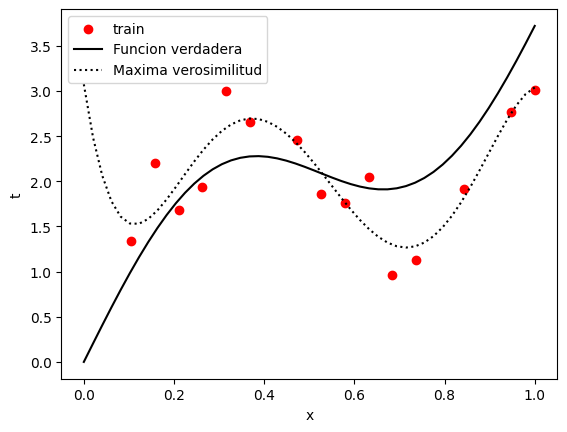

In [ ]:
xvals=np.linspace(0,1,num=50).reshape(-1,1)
plt.scatter(x_train,t_train, c='red', label='train')
plt.plot(xvals,ground_truth(xvals),color='black',label='Funcion verdadera')
plt.plot(xvals,pipe.predict(xvals),color='black',linestyle='dotted',label='Maxima verosimilitud')
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.show()

## Regresión Lineal Múltiple

¿Qué pasa cuando tenemos más de un feature?
Para el caso de dos features:

<!-- $$\vec x=(x_1, x_2)=x_1+x_2\sum_{m=0}^M x_1^{M-m}x_2^m$$ -->
<!-- $$$$ -->
$$\vec x= (x_1, x_2)= (x_1, x_2, x_1^2, x_1x_2, x_2^2,...,x_1x_2^{M-1}, x_2^M)$$

Generamos dos variables de juguete:

In [ ]:
from sklearn.model_selection import train_test_split

N_SAMPLES = 30
x1 = np.linspace(0, 1, num=N_SAMPLES).reshape(-1, 1)
x2 = np.random.rand(N_SAMPLES, 1).reshape(-1, 1)

x = np.hstack([x1, x2])  # Los unimos (20,2)

# Verificación
np.random.seed(42)

# Ground truth aplicada por filas, vectorizada
def ground_truth(X):
    return 4 * X[:, 0] + np.sin(6 * X[:, 1])

t = ground_truth(x).reshape(-1, 1) + 0.5 * np.random.randn(N_SAMPLES, 1)

# Split de entrenamiento y prueba
x_train, x_test, t_train, t_test = train_test_split(x, t, random_state=42)

In [ ]:
degree = 2
pipe_poly = Pipeline([
        ('poly_features', PolynomialFeatures(degree, include_bias=True)),
        ('regressor', LinearRegression(fit_intercept=False))])

pipe_poly.fit(x_train, t_train)

Pipeline(steps=[('poly_features', PolynomialFeatures()),
                ('regressor', LinearRegression(fit_intercept=False))])

In [ ]:
x_train[0]

array([0.4137931 , 0.96958463])

In [ ]:
pipe_poly['poly_features'].transform(x_train)[0]

array([1.        , 0.4137931 , 0.96958463, 0.17122473, 0.40120743,
       0.94009435])

In [ ]:
pipe_poly['regressor'].coef_, pipe_poly['regressor'].intercept_

(array([[ 0.88981785,  2.979861  , -0.01357649,  1.40367507, -1.36199871,
         -1.72914979]]),
 0.0)

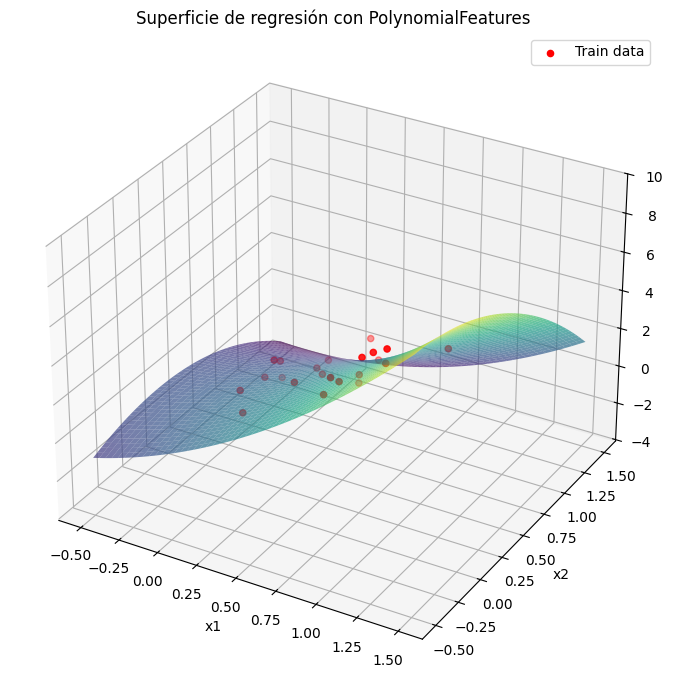

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Crear malla sobre el espacio (x1, x2)
x1_grid, x2_grid = np.meshgrid(
    np.linspace(-0.5, 1.5, 50),
    np.linspace(-0.5, 1.5, 50)
)
x_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]  # (2500, 2)

# Predecir directamente con el pipeline
t_grid_pred = pipe_poly.predict(x_grid).reshape(x1_grid.shape)

# Gráfico 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Superficie
ax.plot_surface(x1_grid, x2_grid, t_grid_pred, alpha=0.7, cmap='viridis', edgecolor='none')

# Puntos de entrenamiento
ax.scatter(x_train[:, 0], x_train[:, 1], t_train.ravel(), color='red', label='Train data')

# Etiquetas
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('t')
ax.set_title('Superficie de regresión con PolynomialFeatures')
ax.legend()

plt.tight_layout()
plt.show()

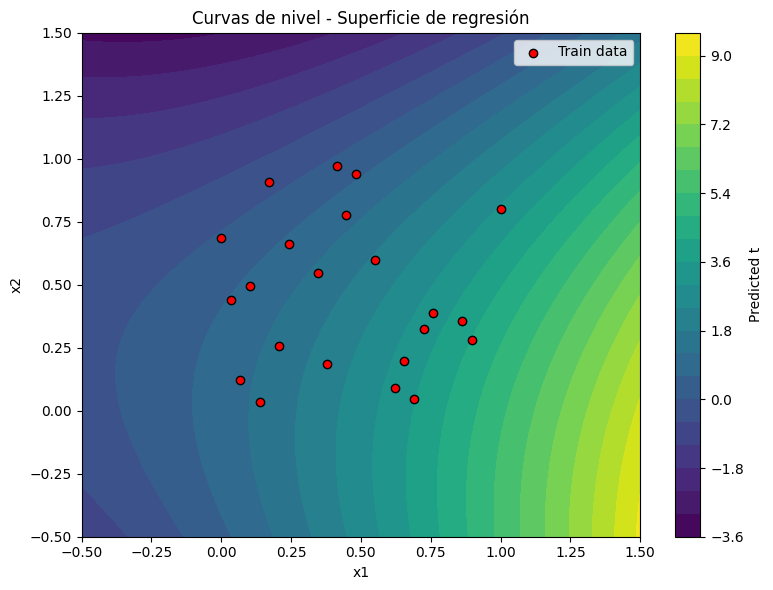

In [ ]:
plt.figure(figsize=(8, 6))
contour = plt.contourf(x1_grid, x2_grid, t_grid_pred, levels=20, cmap='viridis')
plt.colorbar(contour, label='Predicted t')
plt.scatter(x_train[:, 0], x_train[:, 1], c='red', edgecolor='k', label='Train data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Curvas de nivel - Superficie de regresión')
plt.legend()
plt.tight_layout()
plt.show()